In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [5]:
from sklearn.datasets import make_blobs, make_moons

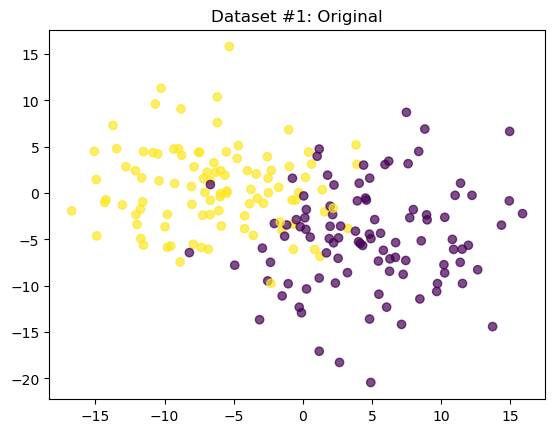

In [6]:
x1, label1 = make_blobs(n_samples=200, n_features=2, centers=2, cluster_std=5, random_state=123)
plt.scatter(x1[0:,0], x1[:,1], c=label1, alpha=0.7)
plt.title('Dataset #1: Original')
plt.show()

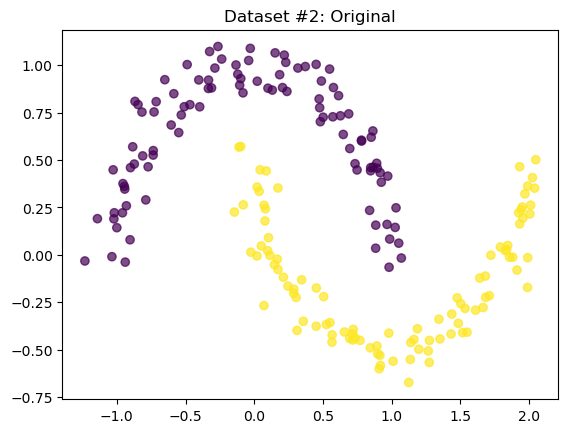

In [7]:
x2, label2 = make_moons(n_samples=200, noise=0.08, random_state=123)
plt.scatter(x2[0:,0], x2[:,1], c=label2, alpha=0.7)
plt.title('Dataset #2: Original')
plt.show()

In [8]:
from sklearn.cluster import AgglomerativeClustering

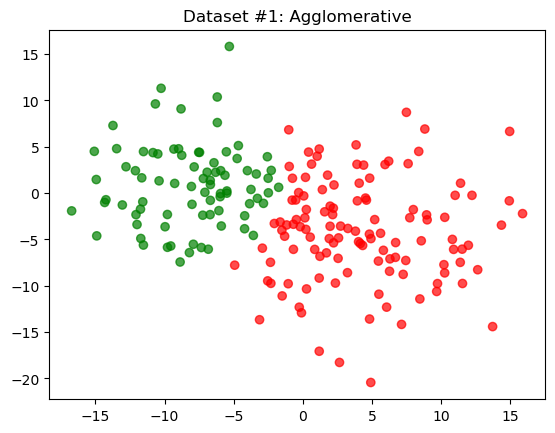

In [9]:
agglo = AgglomerativeClustering(n_clusters=2)
agglo.fit(x1)
myColors = {0: 'red', 1: 'green'}
plt.scatter(x1[:,0], x1[:,1], c=pd.Series(agglo.labels_).apply(lambda x: myColors[x]), alpha=0.7)
plt.title('Dataset #1: Agglomerative')
plt.show()

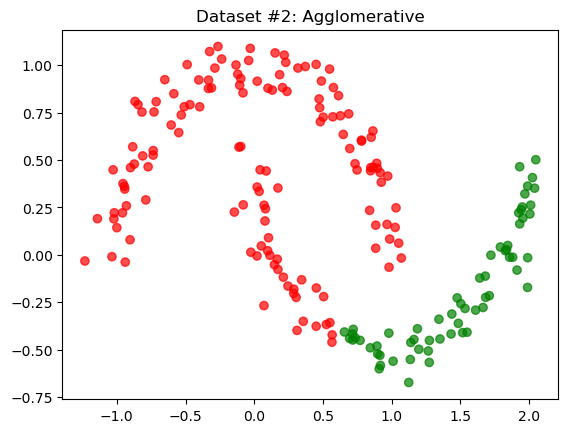

In [10]:
agglo2 = AgglomerativeClustering(n_clusters=2)
agglo2.fit(x2)
plt.scatter(x2[:,0], x2[:,1], c=pd.Series(agglo2.labels_).apply(lambda x: myColors[x]), alpha=0.7)
plt.title('Dataset #2: Agglomerative')
plt.show()

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

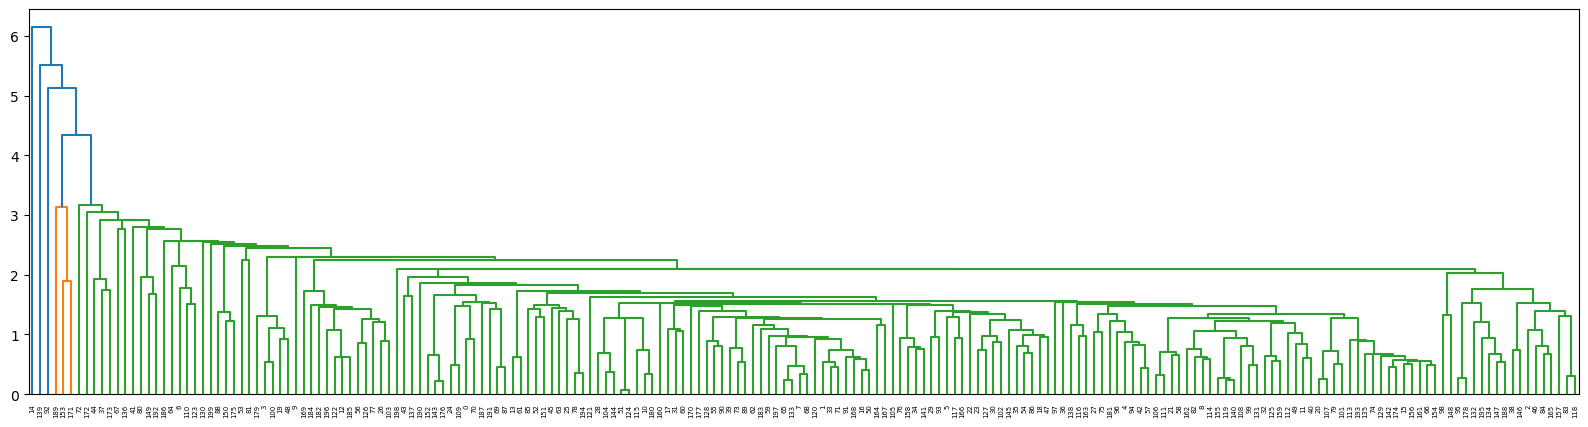

In [12]:
myLinkage = linkage(x1, method='single')
plt.figure(figsize=(20, 5))
dendrogram(myLinkage)
plt.show()

In [13]:
labels = fcluster(myLinkage, 4, criterion='distance')
pd.Series(labels).value_counts()

2    194
1      3
5      1
3      1
4      1
Name: count, dtype: int64

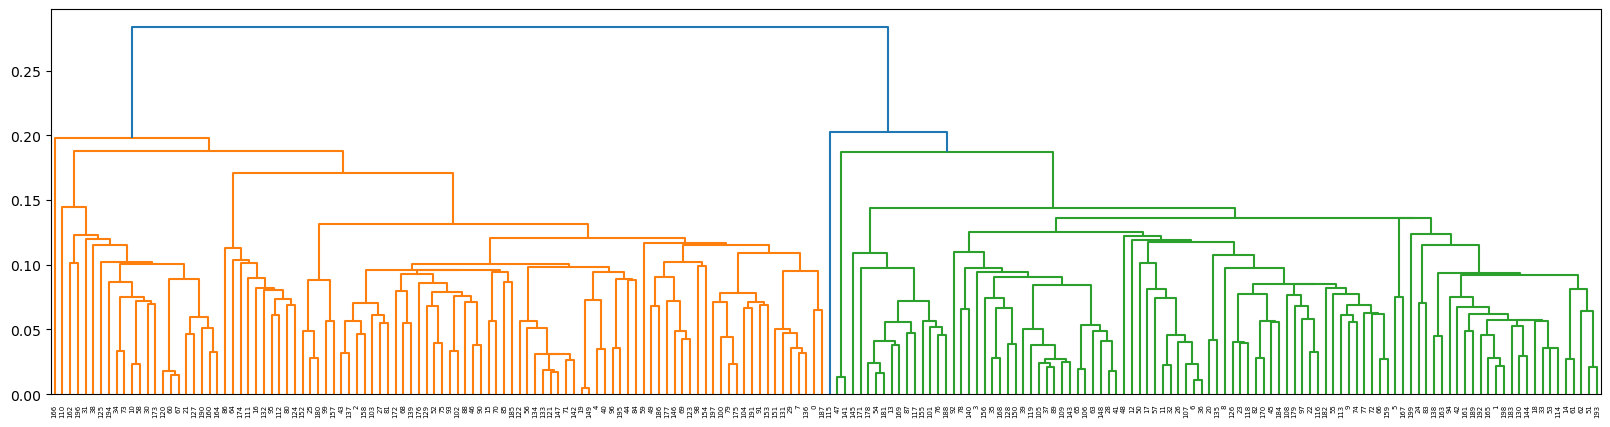

In [14]:
myLinkage2 = linkage(x2, method='single')
plt.figure(figsize=(20,5))
dendrogram(myLinkage2)
plt.show()

In [15]:
labels2 = fcluster(myLinkage2, 0.23, criterion='distance')
pd.Series(labels2).value_counts()

1    100
2    100
Name: count, dtype: int64

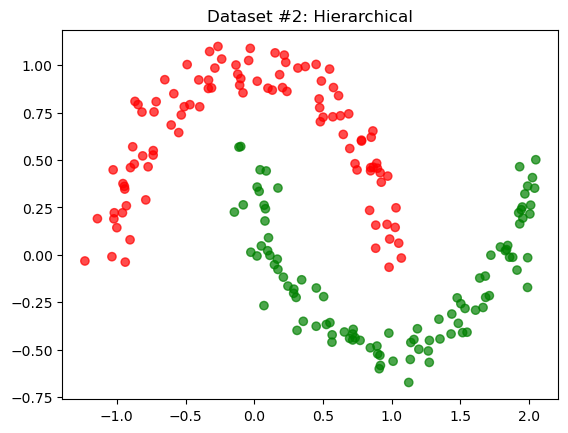

In [17]:
plt.scatter(x2[:,0], x2[:,1], c=pd.Series(labels2).apply(lambda x: myColors[x-1]), alpha=0.7)
plt.title('Dataset #2: Hierarchical')
plt.show()